# Model Fitting - SEIRS-SEI Model

This notebook demonstrates parameter optimization for the SEIRS-SEI (Susceptible-Exposed-Infectious-Recovered for Humans, Susceptible-Exposed-Infectious for Mosquitoes) model using the `epimodels.fitting` module.

## Parameters to Fit

The following parameters will be optimized:
- **b1**: Transmission probability (mosquito to human)
- **b2**: Transmission probability (human to mosquito)
- **T_prime**: Temperature threshold for sporogonic cycle
- **defor_max_effect**: Maximum effect of deforestation on transmission
- **defor_scale**: Scale factor for deforestation effect
- **fire_smoke_effect**: Reduction in biting rate from smoke
- **fire_habitat_effect**: Reduction in larval habitat from fire

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from epimodels.continuous import SEIRS_SEI
from epimodels.fitting import (
    Dataset,
    ParameterSpec,
    ModelFitter,
    ScipyOptimizer,
    SumOfSquaredErrors,
)

%matplotlib inline

## Load Data

In [16]:
DATA_PATH = './data/'

START_DATE = '2017-01-01'
END_DATE = '2023-12-31'

# Load climate data
climate_df = pd.read_csv(f'{DATA_PATH}climate_api_data_2016_2024.csv')
climate_df['date'] = pd.to_datetime(climate_df['date'])

# Load cases data
cases_df = pd.read_csv(f'{DATA_PATH}cumulative_manaus_cases_2016_2023.csv')
cases_df['date'] = pd.to_datetime(cases_df['date'])

# Load fire data
fire_df = pd.read_csv(f'{DATA_PATH}inpe_fire_counts_data_2016_2024.csv')
fire_df['date'] = pd.to_datetime(fire_df['date'])

# Load deforestation data
defor_df = pd.read_csv(f'{DATA_PATH}treated_deter_deforestation_data_2016_2024.csv')
defor_df['date'] = pd.to_datetime(defor_df['date'])

# Filter to study period
climate_df = climate_df[
    (climate_df['date'] >= START_DATE) & 
    (climate_df['date'] <= END_DATE)
].reset_index(drop=True)

cases_df = cases_df[
    (cases_df['date'] >= START_DATE) & 
    (cases_df['date'] <= END_DATE)
].reset_index(drop=True)

fire_df = fire_df[
    (fire_df['date'] >= START_DATE) & 
    (fire_df['date'] <= END_DATE)
].reset_index(drop=True)

defor_df = defor_df[
    (defor_df['date'] >= START_DATE) & 
    (defor_df['date'] <= END_DATE)
].reset_index(drop=True)

# Merge all data
climate_df = climate_df.merge(fire_df[['date', 'fire_counts']], on='date', how='left')
climate_df = climate_df.merge(defor_df[['date', 'total_degradation']], on='date', how='left')
climate_df['fire_counts'] = climate_df['fire_counts'].fillna(0)
climate_df['total_degradation'] = climate_df['total_degradation'].fillna(0)

print(f"Climate data shape: {climate_df.shape}")
print(f"Date range: {climate_df['date'].min()} to {climate_df['date'].max()}")
print(f"Cases data shape: {cases_df.shape}")

Climate data shape: (2556, 18)
Date range: 2017-01-01 00:00:00 to 2023-12-31 00:00:00
Cases data shape: (2556, 11)


## Create Interpolation Functions

In [17]:
# Create day number from start
climate_df['day_number'] = (climate_df['date'] - climate_df['date'].min()).dt.days

# Create interpolation functions
temp_interp = interp1d(
    climate_df['day_number'], 
    climate_df['temp_med'],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)

precip_interp = interp1d(
    climate_df['day_number'],
    climate_df['precip_med'],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)

umid_interp = interp1d(
    climate_df['day_number'],
    climate_df['umid_med'],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)

fire_interp = interp1d(
    climate_df['day_number'],
    climate_df['fire_counts'],
    kind='linear',
    bounds_error=False,
    fill_value=0
)

defor_interp = interp1d(
    climate_df['day_number'],
    climate_df['total_degradation'],
    kind='linear',
    bounds_error=False,
    fill_value=0
)

print("Interpolation functions created.")

Interpolation functions created.


## Prepare Data and Model

In [18]:
# Population parameters
N = 8558  # Human population
M = 100000  # Mosquito population
TOTAL_POPULATION = N + M

# Time points
times = climate_df['day_number'].values

# Observed prevalence (active cases)
observed_prevalence = cases_df['active_total'].values.astype(float)

# Initial conditions
I_H0 = float(cases_df['active_total'].iloc[0])
E_H0 = I_H0 * 0.5  # Estimate exposed from infectious
R_H0 = 0
S_H0 = N - E_H0 - I_H0 - R_H0

# Mosquito initial conditions
E_M0 = 10000
I_M0 = 500
S_M0 = M - E_M0 - I_M0

inits = [S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0]

print(f"Prevalence range: {observed_prevalence.min():.0f} to {observed_prevalence.max():.0f}")
print(f"Time range: {times.min()} to {times.max()} days")
print(f"Initial conditions: S_H0={S_H0:.0f}, E_H0={E_H0:.0f}, I_H0={I_H0:.0f}, R_H0={R_H0:.0f}")

Prevalence range: 410 to 4897
Time range: 0 to 2555 days
Initial conditions: S_H0=5148, E_H0=1136, I_H0=2273, R_H0=0


## Create Model with Environmental Functions

In [19]:
# Create SEIRS-SEI model with environmental functions
model = SEIRS_SEI(
    temp_func=temp_interp,
    precip_func=precip_interp,
    umid_func=umid_interp,
    fire_func=fire_interp,
    defor_func=defor_interp
)

print(f"Model type: {model.model_type}")
print(f"State variables: {list(model.state_variables.keys())}")
print(f"Parameters: {list(model.parameters.keys())}")

Model type: SEIRS-SEI
State variables: ['S_H', 'E_H', 'I_H', 'R_H', 'S_M', 'E_M', 'I_M']
Parameters: ['b1', 'b2', 'gamma', 'r_H', 'omega', 'tau_H', 'BE', 'pME', 'pML', 'pMP', 'tauE', 'tauP', 'c1', 'c2', 'D1', 'A', 'B', 'C', 'DD', 'Tmin', 'T_prime', 'R_L', 'defor_max_effect', 'defor_scale', 'defor_delay', 'fire_smoke_effect', 'fire_habitat_effect', 'fire_recovery_delay']


## Create Dataset

In [20]:
# Create dataset and register observed data
dataset = Dataset(model)

# Register the 'I_H' compartment data (infectious humans)
dataset.register(
    name='infectious_humans',
    values=observed_prevalence,
    times=times,
    state_variable='I_H',
    time_unit='days',
)

# Validate the dataset
validation_result = dataset.validate(total_population=TOTAL_POPULATION)
print(f"Dataset valid: {validation_result.is_valid}")
print(f"Time range: {dataset.time_range}")
print(dataset)

Dataset valid: True
Time range: (0.0, 2555.0)
Dataset(n_series=1, variables=['I_H'], time_range=(0.0, 2555.0))


## Define Parameters to Fit

In [21]:
# Define parameter specifications
param_specs = [
    ParameterSpec(
        name='b1',
        bounds=(0.1, 0.99),
        initial=0.5,
    ),
    ParameterSpec(
        name='b2',
        bounds=(0.1, 0.99),
        initial=0.5,
    ),
    ParameterSpec(
        name='T_prime',
        bounds=(18.0, 32.0),
        initial=25.0,
    ),
    ParameterSpec(
        name='defor_max_effect',
        bounds=(0.1, 0.5),
        initial=0.3,
    ),
    ParameterSpec(
        name='defor_scale',
        bounds=(0.00001, 0.001),
        initial=0.0001,
    ),
    ParameterSpec(
        name='fire_smoke_effect',
        bounds=(0.2, 0.6),
        initial=0.4,
    ),
    ParameterSpec(
        name='fire_habitat_effect',
        bounds=(0.1, 0.4),
        initial=0.2,
    ),
]

print("Parameters to fit:")
for spec in param_specs:
    print(f"  {spec.name}: bounds={spec.bounds}, initial={spec.initial}")

Parameters to fit:
  b1: bounds=(0.1, 0.99), initial=0.5
  b2: bounds=(0.1, 0.99), initial=0.5
  T_prime: bounds=(18.0, 32.0), initial=25.0
  defor_max_effect: bounds=(0.1, 0.5), initial=0.3
  defor_scale: bounds=(1e-05, 0.001), initial=0.0001
  fire_smoke_effect: bounds=(0.2, 0.6), initial=0.4
  fire_habitat_effect: bounds=(0.1, 0.4), initial=0.2


## Define Fixed Parameters

In [22]:
# Fixed parameters (not to be optimized)
fixed_params = {
    # Human disease dynamics
    'gamma': 1/60,  # recovery rate (~60 days)
    'r_H': 0.00005,  # net human growth rate
    'omega': 1/365,  # immunity loss rate (~1 year)
    'tau_H': 10,  # human incubation period (days)
    
    # Mosquito life cycle
    'BE': 200,
    'tauE': 1,
    'tauP': 1,
    'D1': 4.0,
    'pME': 0.9,
    'pML': 0.25,
    'pMP': 0.75,
    'c1': 0.00554,
    'c2': -0.06737,
    
    # Temperature-dependent survival
    'A': 12.5,
    'B': 15.0,
    'C': -48.78,
    
    # Sporogonic cycle
    'DD': 105,  # degree-days
    'Tmin': 14.5,
    
    # Larval habitat
    'R_L': 32.67,  # rainfall threshold for breeding
    
    # Environmental modification parameters
    'defor_delay': 14,
    'fire_recovery_delay': 21,
    
    # Population sizes
    'N': N,
    'M': M
}

print("Fixed parameters:", list(fixed_params.keys()))

Fixed parameters: ['gamma', 'r_H', 'omega', 'tau_H', 'BE', 'tauE', 'tauP', 'D1', 'pME', 'pML', 'pMP', 'c1', 'c2', 'A', 'B', 'C', 'DD', 'Tmin', 'R_L', 'defor_delay', 'fire_recovery_delay', 'N', 'M']


## Create Fitter and Run Optimization

In [23]:
# =============================================================================
# Fit Initial Conditions Only
# =============================================================================

from epimodels.fitting import InitialConditionSpec, MultiStartOptimizer

# Define initial condition specs - fit S_H and R_H only
ic_specs = [
    InitialConditionSpec(
        state_variable='S_H',
        bounds=(0, N),
        initial=S_H0,
        fixed=False,  # Fit S_H
    ),
    InitialConditionSpec(
        state_variable='E_H',
        bounds=(E_H0 * 0.5, E_H0 * 2),
        initial=E_H0,
        fixed=True,  # Keep E_H fixed
    ),
    InitialConditionSpec(
        state_variable='I_H',
        bounds=(I_H0 * 0.5, I_H0 * 2),
        initial=I_H0,
        fixed=True,  # Keep I_H fixed
    ),
    InitialConditionSpec(
        state_variable='R_H',
        bounds=(0, N),
        initial=R_H0,
        fixed=False,  # Fit R_H
    ),
    InitialConditionSpec(
        state_variable='S_M',
        bounds=(M * 0.5, M * 1.5),
        initial=S_M0,
        fixed=True,  # Keep mosquito compartments fixed
    ),
    InitialConditionSpec(
        state_variable='E_M',
        bounds=(E_M0 * 0.5, E_M0 * 2),
        initial=E_M0,
        fixed=True,
    ),
    InitialConditionSpec(
        state_variable='I_M',
        bounds=(I_M0 * 0.5, I_M0 * 2),
        initial=I_M0,
        fixed=True,
    ),
]

# Fixed parameter values (use default values)
all_fixed_params = {
    **fixed_params,
    'b1': 0.5,
    'b2': 0.5,
    'T_prime': 25.0,
    'defor_max_effect': 0.3,
    'defor_scale': 0.0001,
    'fire_smoke_effect': 0.4,
    'fire_habitat_effect': 0.2,
}

# Multi-start optimizer for robust results
base_optimizer = ScipyOptimizer(method='L-BFGS-B', max_iterations=50)
multi_start = MultiStartOptimizer(
    base_optimizer=base_optimizer,
    n_starts=10,
    sampling_method='latin_hypercube',
    seed=42,
)

# Create fitter with multi-start optimization
fitter = ModelFitter(
    model=model,
    dataset=dataset,
    parameters_to_fit=[],  # No parameters to fit
    total_population=TOTAL_POPULATION,
    fixed_params=all_fixed_params,
    optimizer=multi_start,
    loss_fn=SumOfSquaredErrors(),
    fit_initial_conditions=True,
    initial_condition_specs=ic_specs,
)

print("="*60)
print("FITTING INITIAL CONDITIONS (Multi-Start)")
print("="*60)
result = fitter.fit()

print(f"Convergence: {result.convergence}")
print(f"Loss: {result.best_loss:.2f}")

# Get fitted initial conditions
fitted_inits = result.best_initial_conditions
state_vars = list(model.state_variables.keys())
print(f"Fitted Initial Conditions:")
for var, val in zip(state_vars, fitted_inits):
    print(f"{var}[0]: {val:.2f}")

# Also run model with fitted ICs for later use
fitted_model = result.fitted_model
fitted_I_H = np.interp(times, fitted_model.traces['time'], fitted_model.traces['I_H'])

# Calculate metrics
residuals = observed_prevalence - fitted_I_H
rmse = np.sqrt(np.mean(residuals**2))
from scipy.stats import pearsonr
pearson_r, _ = pearsonr(observed_prevalence, fitted_I_H)

print(f"Model fit metrics:")
print(f"Pearson R: {pearson_r:.4f}")
print(f"RMSE: {rmse:.2f}")


FITTING INITIAL CONDITIONS (Multi-Start)


C:\Users\rapha\epimodels\epimodels\fitting\base.py:412: RuntimeWarning: Model evaluation failed: Sum of initial conditions (120525.5) exceeds total population (108558)
  warnings.warn(f"Model evaluation failed: {e}", RuntimeWarning)
C:\Users\rapha\epimodels\epimodels\fitting\base.py:412: RuntimeWarning: Model evaluation failed: Sum of initial conditions (120525.49999999) exceeds total population (108558)
  warnings.warn(f"Model evaluation failed: {e}", RuntimeWarning)
C:\Users\rapha\epimodels\epimodels\fitting\base.py:412: RuntimeWarning: Model evaluation failed: Sum of initial conditions (112547.16666585045) exceeds total population (108558)
  warnings.warn(f"Model evaluation failed: {e}", RuntimeWarning)
C:\Users\rapha\epimodels\epimodels\fitting\base.py:412: RuntimeWarning: Model evaluation failed: Sum of initial conditions (112547.16666586045) exceeds total population (108558)
  warnings.warn(f"Model evaluation failed: {e}", RuntimeWarning)
C:\Users\rapha\epimodels\epimodels\fittin

Convergence: False
Loss: 4632663147.22
Fitted Initial Conditions:
S_H[0]: 5148.50
E_H[0]: 1136.50
I_H[0]: 2273.00
R_H[0]: 0.00
S_M[0]: 89500.00
E_M[0]: 10000.00
I_M[0]: 500.00
Model fit metrics:
Pearson R: 0.4185
RMSE: 1375.56


## Run Model with Fitted Parameters

In [24]:
# Get fitted model
fitted_model = result.fitted_model

# Extract fitted I_H
fitted_I_H = np.interp(times, fitted_model.traces['time'], fitted_model.traces['I_H'])

dates = cases_df['date'].values

## Plot Results

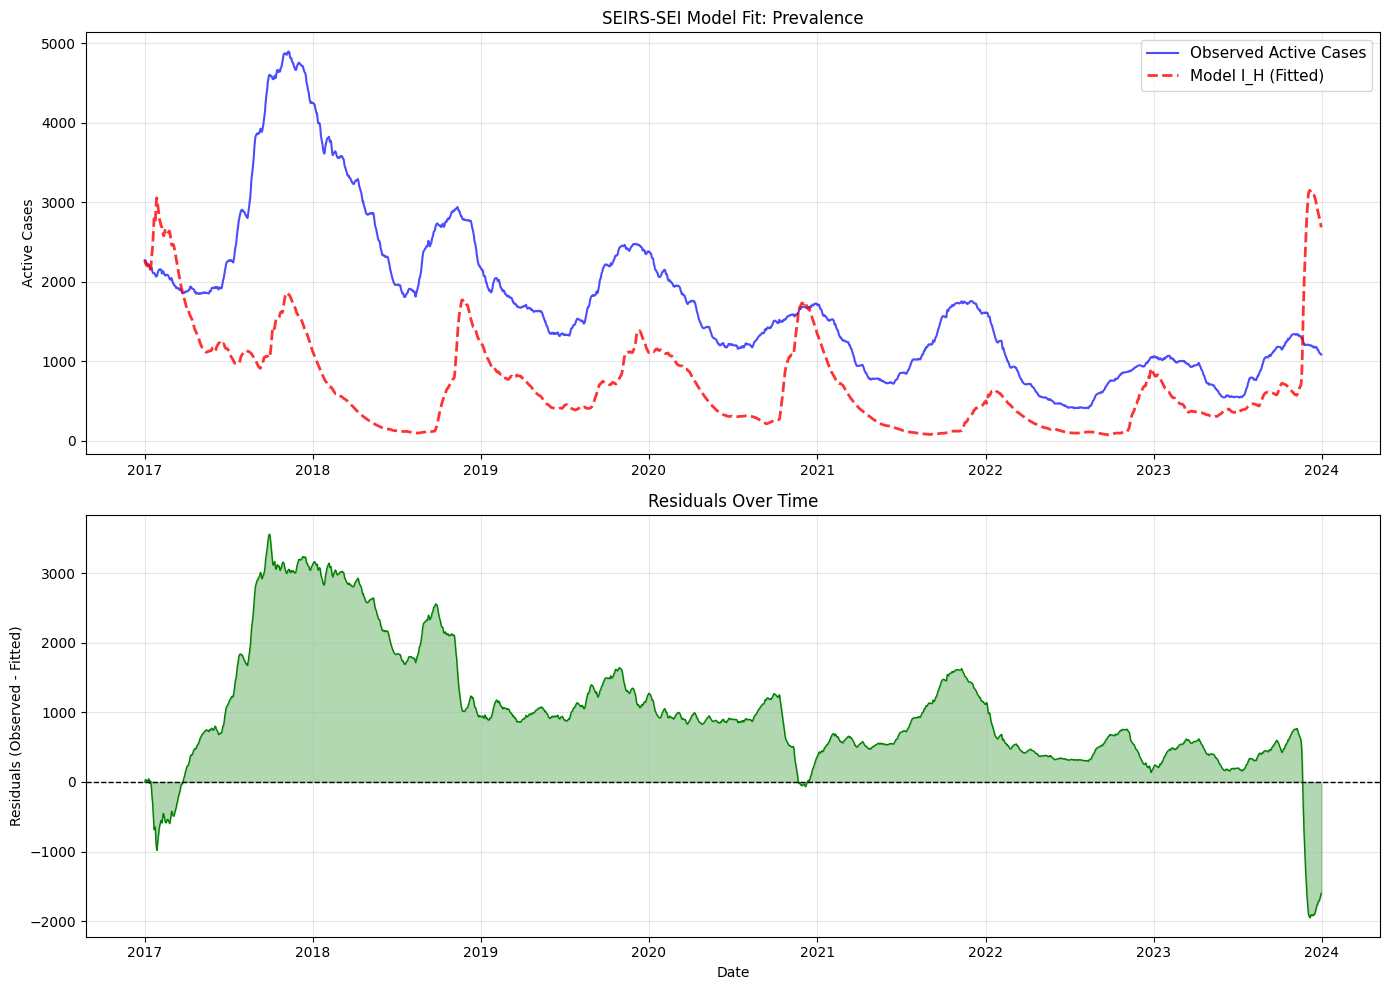

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Observed vs Fitted
axes[0].plot(dates, observed_prevalence, 'b-', alpha=0.7, label='Observed Active Cases', linewidth=1.5)
axes[0].plot(dates, fitted_I_H, 'r--', alpha=0.8, label='Model I_H (Fitted)', linewidth=2)
axes[0].set_ylabel('Active Cases')
axes[0].set_title('SEIRS-SEI Model Fit: Prevalence')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = observed_prevalence - fitted_I_H
axes[1].plot(dates, residuals, 'g-', linewidth=1)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=1)
axes[1].fill_between(dates, residuals, 0, alpha=0.3, color='green')
axes[1].set_ylabel('Residuals (Observed - Fitted)')
axes[1].set_xlabel('Date')
axes[1].set_title('Residuals Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Diagnostics

In [26]:
# Calculate error metrics
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

# Pearson correlation
from scipy.stats import pearsonr, spearmanr
pearson_r, pearson_p = pearsonr(observed_prevalence, fitted_I_H)
spearman_r, spearman_p = spearmanr(observed_prevalence, fitted_I_H)

print(f"{'='*60}")
print("MODEL FIT DIAGNOSTICS")
print(f"{'='*60}")
print(f"Pearson correlation: {pearson_r:.4f} (p-value: {pearson_p:.2e})")
print(f"Spearman correlation: {spearman_r:.4f} (p-value: {spearman_p:.2e})")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"{'='*60}")

MODEL FIT DIAGNOSTICS
Pearson correlation: 0.4185 (p-value: 6.44e-109)
Spearman correlation: 0.5569 (p-value: 3.31e-208)
RMSE: 1375.56
MAE: 1103.86


## Parameter Summary

In [27]:
# Initial Condition Summary
state_vars = list(model.state_variables.keys())

print(f"{'='*60}")
print("INITIAL CONDITION SUMMARY")
print(f"{'='*60}")
print(f"{'State Variable':<15} {'Initial':>12} {'Fitted':>12} {'Change (%)':>12}")
print("-"*60)

# Get initial conditions used
if hasattr(result, 'best_initial_conditions') and result.best_initial_conditions:
    fitted_ics = result.best_initial_conditions
else:
    fitted_ics = inits  # Use original inits

# Original values
original_ics = [S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0]

for var, orig, fitted in zip(state_vars, original_ics, fitted_ics):
    if orig != 0:
        change = ((fitted - orig) / orig * 100)
        print(f"{var:<15} {orig:>12.2f} {fitted:>12.2f} {change:>11.2f}%")
    else:
        print(f"{var:<15} {orig:>12.2f} {fitted:>12.2f} {'N/A':>12}")
print(f"{'='*60}")


INITIAL CONDITION SUMMARY
State Variable       Initial       Fitted   Change (%)
------------------------------------------------------------
S_H                  5148.50      5148.50        0.00%
E_H                  1136.50      1136.50        0.00%
I_H                  2273.00      2273.00        0.00%
R_H                     0.00         0.00          N/A
S_M                 89500.00     89500.00        0.00%
E_M                 10000.00     10000.00        0.00%
I_M                   500.00       500.00        0.00%


## Save Fitted Parameters

In [28]:
# Combine fixed and fitted parameters
all_params = {**fixed_params, **result.best_params}

print("All model parameters:")
for k, v in all_params.items():
    print(f"  {k}: {v}")

All model parameters:
  gamma: 0.016666666666666666
  r_H: 5e-05
  omega: 0.0027397260273972603
  tau_H: 10
  BE: 200
  tauE: 1
  tauP: 1
  D1: 4.0
  pME: 0.9
  pML: 0.25
  pMP: 0.75
  c1: 0.00554
  c2: -0.06737
  A: 12.5
  B: 15.0
  C: -48.78
  DD: 105
  Tmin: 14.5
  R_L: 32.67
  defor_delay: 14
  fire_recovery_delay: 21
  N: 8558
  M: 100000
